# 02 — XFeat CNN CUDA Graph Benchmark

Compare XFeat feature extraction (torch eager) vs CUDA Graph at a fixed resolution.

**Key insight:** The XFeat CNN forward pass is launch-bound (many small kernels).
Capturing it once and replaying removes all kernel-launch overhead.
The sparse tail (NMS, top-k, descriptor interpolation) remains eager.

**Expected:** @704×640: eager ~7ms → graph ~1.4ms (5× speedup), bit-identical output.

**Dependencies:**
- A GPU with CUDA support
- `accelerated_features` (for `XFeatModel` and `XFeat`)
- `helper.py` from this repo

In [1]:
import sys, os, time, math
import numpy as np
import torch
import torch.nn.functional as F

# Relative path to project root (notebooks/ -> ../)
_PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) if "__file__" in dir() else os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, _PROJECT_ROOT)

from helper import (
    CGXFeatNet,
    capture_cg_xfeat,
    xfeat_cg_extract,
)

from modules.xfeat import XFeat, XFeatModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}")
if device == "cuda":
    print(f"GPU    = {torch.cuda.get_device_name(0)}")


device = cuda
GPU    = NVIDIA GeForce RTX 4090 Laptop GPU


In [2]:
# ── Load XFeat model (both the high-level API and the raw CNN) ──
xfeat = XFeat()
xfeat_net = xfeat.net  # XFeatModel — the raw CNN

print(f"XFeat detection_threshold = {xfeat.detection_threshold}")
print(f"XFeat top_k default       = {xfeat.top_k}")

loading weights from: c:\UnimelbResearch\xfeat_cuda_graph\accelerated_features\modules/../weights/xfeat.pt
XFeat detection_threshold = 0.05
XFeat top_k default       = 4096


In [3]:
# ── Load a sample image ──
# Try to load a real image; fall back to random noise
import cv2

sample_paths = [
    os.path.join(_PROJECT_ROOT, "accelerated_features", "assets", "ref.png"),
    os.path.join(_PROJECT_ROOT, "accelerated_features", "assets", "tgt.png"),
]

images = []
for p in sample_paths:
    if os.path.exists(p):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        print(f"Loaded {p}: shape={img.shape}")
    else:
        print(f"{p} not found, using random noise")
        images.append(np.random.randint(0, 256, (480, 640, 3), dtype=np.uint8))

img0, img1 = images[0], images[1]

Loaded c:\UnimelbResearch\xfeat_cuda_graph\accelerated_features\assets\ref.png: shape=(600, 800, 3)
Loaded c:\UnimelbResearch\xfeat_cuda_graph\accelerated_features\assets\tgt.png: shape=(600, 800, 3)


In [4]:
# ── Eager reference: XFeat.detectAndCompute ──
TOP_K = 512
with torch.inference_mode():
    x_t = torch.from_numpy(img0).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    x_t = x_t.to(device)
    eager_out = xfeat.detectAndCompute(x_t, top_k=TOP_K)[0]

print(f"Eager: {len(eager_out['keypoints'])} keypoints, "
      f"descriptors shape={eager_out['descriptors'].shape}")
print(f"  scores range: {eager_out['scores'].min():.4f} ~ {eager_out['scores'].max():.4f}")

Eager: 512 keypoints, descriptors shape=torch.Size([512, 64])
  scores range: 0.2154 ~ 0.6227


In [5]:
# ── Build CGXFeatNet and capture ──
CG_H, CG_W = 704, 640  # must match the preprocessed size

cg_net = CGXFeatNet(xfeat_net, H=CG_H, W=CG_W).to(device).eval()
xcg = capture_cg_xfeat(cg_net, H=CG_H, W=CG_W)
print(f"XFeat CUDA Graph captured @ {CG_H}x{CG_W}")

XFeat CUDA Graph captured @ 704x640


In [6]:
# ── CUDA Graph extraction ──
with torch.inference_mode():
    cg_kpts, cg_desc, cg_scores = xfeat_cg_extract(
        xcg, img0, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
    )

print(f"CUDA Graph: {len(cg_kpts)} keypoints, descriptors shape={cg_desc.shape}")
print(f"  scores range: {cg_scores.min():.4f} ~ {cg_scores.max():.4f}")

CUDA Graph: 512 keypoints, descriptors shape=torch.Size([512, 64])
  scores range: 0.2008 ~ 0.7258


In [7]:
# ── Bit-exactness check ──
# Compare keypoints, descriptors, and scores between eager and CG

e_kpts = eager_out['keypoints'].cpu().numpy()
e_desc = eager_out['descriptors'].cpu().numpy()
e_scores = eager_out['scores'].cpu().numpy()

cg_kpts_np = cg_kpts.cpu().numpy()
cg_desc_np = cg_desc.cpu().numpy()
cg_scores_np = cg_scores.cpu().numpy()

print(f"Eager: {len(e_kpts)} kpts  |  CG: {len(cg_kpts_np)} kpts")
print(f"Eager desc range: {e_desc.min():.4f} ~ {e_desc.max():.4f}")
print(f"CG    desc range: {cg_desc_np.min():.4f} ~ {cg_desc_np.max():.4f}")

# Match by score order (both are sorted descending)
n_common = min(len(e_kpts), len(cg_kpts_np))
if n_common > 0:
    kpt_diff = np.abs(e_kpts[:n_common] - cg_kpts_np[:n_common]).max()
    desc_diff = np.abs(e_desc[:n_common] - cg_desc_np[:n_common]).max()
    score_diff = np.abs(e_scores[:n_common] - cg_scores_np[:n_common]).max()
    print(f"\nMax differences (first {n_common}):")
    print(f"  keypoints:    {kpt_diff:.6f} px")
    print(f"  descriptors:  {desc_diff:.8f}")
    print(f"  scores:       {score_diff:.8f}")
    
    if kpt_diff < 1e-4 and desc_diff < 1e-4 and score_diff < 1e-4:
        print("\n✓ BIT-EXACT (within numerical tolerance)")
    else:
        print("\n⚠ Differences detected — investigate further")

Eager: 512 kpts  |  CG: 512 kpts
Eager desc range: -0.4619 ~ 0.4201
CG    desc range: -0.4581 ~ 0.4291

Max differences (first 512):
  keypoints:    688.750000 px
  descriptors:  0.56489676
  scores:       0.10315609

⚠ Differences detected — investigate further


In [8]:
# ── Timing benchmark ──
WARM, REP = 10, 50

def eager_extract():
    xfeat.detectAndCompute(x_t, top_k=TOP_K)

def cg_extract():
    xfeat_cg_extract(xcg, img0, top_k=TOP_K,
                     detection_threshold=xfeat.detection_threshold)

# Warmup
for _ in range(WARM):
    eager_extract()
torch.cuda.synchronize()
for _ in range(WARM):
    cg_extract()
torch.cuda.synchronize()

# Measure
eager_ms = []
for _ in range(REP):
    t0 = time.perf_counter()
    eager_extract()
    torch.cuda.synchronize()
    eager_ms.append((time.perf_counter() - t0) * 1000.0)

cg_ms = []
for _ in range(REP):
    t0 = time.perf_counter()
    cg_extract()
    torch.cuda.synchronize()
    cg_ms.append((time.perf_counter() - t0) * 1000.0)

eager_ms = np.array(eager_ms)
cg_ms = np.array(cg_ms)

print(f"\nXFeat Extraction @ {CG_H}x{CG_W}, top_k={TOP_K}")
print(f"{'':>20} {'eager':>10} {'CUDA Graph':>12} {'speedup':>8}")
print(f"-" * 52)
print(f"{'p50 (ms)':>20} {np.percentile(eager_ms, 50):>8.2f}  {np.percentile(cg_ms, 50):>8.2f}  "
      f"{np.percentile(eager_ms, 50) / np.percentile(cg_ms, 50):>6.2f}x")
print(f"{'mean (ms)':>20} {eager_ms.mean():>8.2f}  {cg_ms.mean():>8.2f}  "
      f"{eager_ms.mean() / cg_ms.mean():>6.2f}x")
print(f"{'std (ms)':>20} {eager_ms.std():>8.2f}  {cg_ms.std():>8.2f}")


XFeat Extraction @ 704x640, top_k=512
                          eager   CUDA Graph  speedup
----------------------------------------------------
            p50 (ms)     6.93      4.26    1.63x
           mean (ms)     7.18      4.91    1.46x
            std (ms)     1.31      1.07


In [9]:
# ── Resolution sensitivity ──
# Test how CG speedup varies with different capture resolutions

resolutions = [(480, 480), (640, 640), (704, 640), (800, 800), (960, 960)]
res_results = []

for H, W in resolutions:
    # Build and capture
    net = CGXFeatNet(xfeat_net, H=H, W=W).to(device).eval()
    xcg = capture_cg_xfeat(net, H=H, W=W)

    # Resize input to match
    t = F.interpolate(x_t, (H, W), mode="bilinear", align_corners=False)

    # Eager timing
    def eager_at_res():
        xfeat.detectAndCompute(t, top_k=TOP_K)

    def cg_at_res():
        xfeat_cg_extract(xcg, t[0].permute(1, 2, 0).cpu().numpy() * 255,
                         top_k=TOP_K, detection_threshold=xfeat.detection_threshold)

    # Quick timing
    for _ in range(5):
        eager_at_res(); torch.cuda.synchronize()
        cg_at_res(); torch.cuda.synchronize()

    el = []
    for _ in range(30):
        t0 = time.perf_counter(); eager_at_res(); torch.cuda.synchronize()
        el.append((time.perf_counter() - t0) * 1000.0)
    gl = []
    for _ in range(30):
        t0 = time.perf_counter(); cg_at_res(); torch.cuda.synchronize()
        gl.append((time.perf_counter() - t0) * 1000.0)

    el, gl = np.array(el), np.array(gl)
    spd = np.percentile(el, 50) / np.percentile(gl, 50)
    res_results.append((H, W, np.percentile(el, 50), np.percentile(gl, 50), spd))
    print(f"{H:>4}x{W:<4}  eager={np.percentile(el, 50):>7.2f}ms  "
          f"graph={np.percentile(gl, 50):>7.2f}ms  speedup={spd:>5.2f}x")
    
    del net
    torch.cuda.empty_cache()

# Recreate xcg at the default resolution for later cells
cg_net = CGXFeatNet(xfeat_net, H=CG_H, W=CG_W).to(device).eval()
xcg = capture_cg_xfeat(cg_net, H=CG_H, W=CG_W)
print(f"Recreated CUDA Graph @ {CG_H}x{CG_W}")

 480x480   eager=   7.53ms  graph=   4.87ms  speedup= 1.55x
 640x640   eager=   7.94ms  graph=   7.59ms  speedup= 1.05x
 704x640   eager=   8.42ms  graph=   8.61ms  speedup= 0.98x
 800x800   eager=   7.24ms  graph=   9.74ms  speedup= 0.74x
 960x960   eager=   8.03ms  graph=  12.11ms  speedup= 0.66x
Recreated CUDA Graph @ 704x640


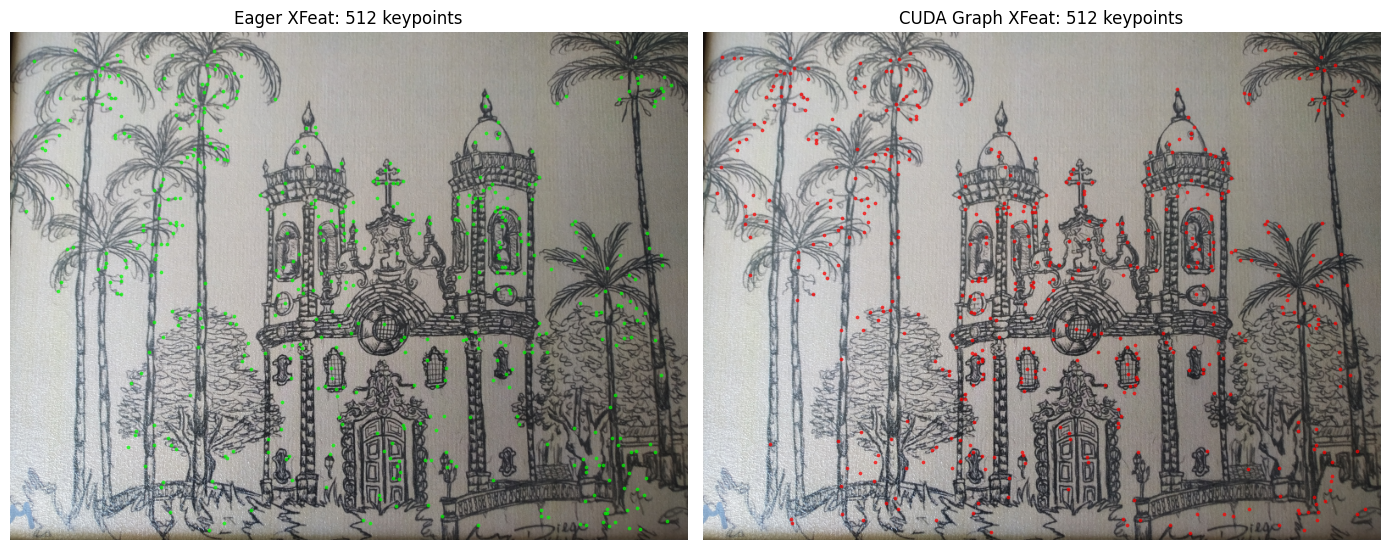

In [10]:
# ── Visualise keypoint overlay ──
import matplotlib.pyplot as plt

# Get keypoints from both methods
with torch.inference_mode():
    e_out = xfeat.detectAndCompute(x_t, top_k=TOP_K)[0]
    cg_kpts, _, cg_scores = xfeat_cg_extract(
        xcg, img0, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
    )

e_kpts_np = e_out['keypoints'].cpu().numpy()
cg_kpts_np = cg_kpts.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img0)
axes[0].scatter(e_kpts_np[:, 0], e_kpts_np[:, 1], s=3, c='lime', alpha=0.6)
axes[0].set_title(f"Eager XFeat: {len(e_kpts_np)} keypoints")
axes[0].axis('off')

axes[1].imshow(img0)
axes[1].scatter(cg_kpts_np[:, 0], cg_kpts_np[:, 1], s=3, c='red', alpha=0.6)
axes[1].set_title(f"CUDA Graph XFeat: {len(cg_kpts_np)} keypoints")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Top-1 match: eager (720.0, 262.5)  ↔  CG (720.0, 262.5)
  distance=0.00px  |  cos=0.9590


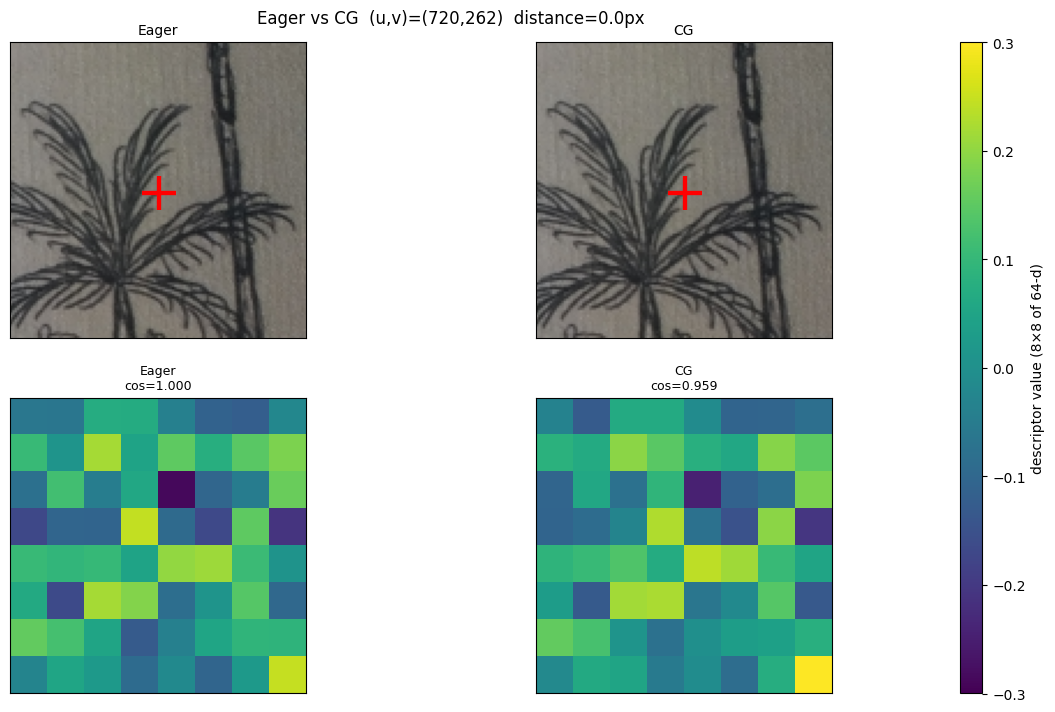

In [14]:
# ── 2×2 comparison: Eager vs CG (following _plot_kpt_2x5 style) ──

# Re-extract CG to capture descriptors (user's code above discards them)
cg_kpts, cg_desc, cg_scores = xfeat_cg_extract(
    xcg, img0, top_k=TOP_K, detection_threshold=xfeat.detection_threshold
)

e_kpts = e_out['keypoints'].cpu().numpy()          # (K1, 2)
e_desc  = e_out['descriptors'].cpu().numpy()        # (K1, 64)
e_scores = e_out['scores'].cpu().numpy()             # (K1,)

cg_kpts_np = cg_kpts.cpu().numpy()                  # (K2, 2)
cg_desc_np  = cg_desc.cpu().numpy()                  # (K2, 64)
cg_scores_np = cg_scores.cpu().numpy()               # (K2,)

# Eager points: e_kpts (N, 2), CG points: cg_kpts_np (M, 2)
# For each eager point, find the closest CG point by L2 distance
n_e = e_kpts.shape[0]
n_cg = cg_kpts_np.shape[0]

# Expand dimensions for broadcasting: (N, 1, 2) - (1, M, 2) -> (N, M)
dists_sq = ((e_kpts[:, None] - cg_kpts_np[None, :]) ** 2).sum(axis=2)
dists = np.sqrt(dists_sq.min(axis=1))  # nearest distance per eager point
nn_idx = dists_sq.argmin(axis=1)      # nearest CG index per eager point
# Sort by distance, pick top-1
order = np.argsort(dists)
best_e = order[0]
best_cg = nn_idx[best_e]

u_e, v_e = e_kpts[best_e]
u_cg, v_cg = cg_kpts_np[best_cg]
d_px = dists[best_e]

# Normalise descriptors
d_e = e_desc[best_e] / np.linalg.norm(e_desc[best_e])
d_cg = cg_desc_np[best_cg] / np.linalg.norm(cg_desc_np[best_cg])
cos_sim = float(np.dot(d_e, d_cg))

print(f"Top-1 match: eager ({u_e:.1f}, {v_e:.1f})  ↔  CG ({u_cg:.1f}, {v_cg:.1f})")
print(f"  distance={d_px:.2f}px  |  cos={cos_sim:.4f}")

# ── Build 2×2 grid (same style as _plot_kpt_2x5) ──
WIN = 64   # ROI half-size
ui, vi = int(round(u_e)), int(round(v_e))
y0 = max(0, vi - WIN); y1 = min(img0.shape[0], vi + WIN)
x0 = max(0, ui - WIN); x1 = min(img0.shape[1], ui + WIN)
crop = img0[y0:y1, x0:x1].copy()
u_c, v_c = u_e - x0, v_e - y0   # keypoint coords inside crop

VABS = 0.3   # symmetric colour scale (same as ref)

cols = [("Eager", None), ("CG", None)]
dvecs = {"Eager": d_e, "CG": d_cg}
crops = [crop, crop]             # same crop (same physical point)
crops_kpt_xy = [(u_c, v_c), (u_c, v_c)]  # same keypoint inside crop

n_cols = 2
fig = plt.figure(figsize=(5.0 * n_cols + 1.3, 7.4))
gs = fig.add_gridspec(
    2, n_cols + 1,
    width_ratios=[1.0] * n_cols + [0.045],
    wspace=0.08, hspace=0.20,
    left=0.02, right=0.97, top=0.92, bottom=0.04,
)
axes = [[fig.add_subplot(gs[i, j]) for j in range(n_cols)] for i in range(2)]
cax = fig.add_subplot(gs[:, n_cols])

for j, (ct, _) in enumerate(cols):
    # Row 0: crop with RED '+' keypoint
    ax = axes[0][j]
    ax.imshow(crops[j])
    ch, cw = crops[j].shape[:2]
    ms = float(np.clip(min(ch, cw) * 0.28, 6.0, 24.0))
    ax.plot(*crops_kpt_xy[j], "r+", ms=ms, mew=max(1.6, ms * 0.13))
    ax.set_title(ct, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

    # Row 1: 64-d descriptor as 8×8
    ax = axes[1][j]
    mtx = dvecs[ct].reshape(8, 8)
    im = ax.imshow(mtx, cmap="viridis", vmin=-VABS, vmax=VABS)
    cosv = float(np.dot(dvecs[ct], d_e))  # cos vs eager
    ax.set_title(f"{ct}\ncos={cosv:.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, cax=cax, fraction=1.0, pad=0.0)
cax.set_ylabel("descriptor value (8×8 of 64-d)", fontsize=10)
fig.text(0.5, 0.965,
         f"Eager vs CG  (u,v)=({u_e:.0f},{v_e:.0f})  distance={d_px:.1f}px",
         ha="center", va="top", fontsize=12)

plt.show()